# Data Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset = pd.read_csv('MITData.csv')

In [3]:
dataset.columns

Index(['record', 'type', '0_pre-RR', '0_post-RR', '0_pPeak', '0_tPeak',
       '0_rPeak', '0_sPeak', '0_qPeak', '0_qrs_interval', '0_pq_interval',
       '0_qt_interval', '0_st_interval', '0_qrs_morph0', '0_qrs_morph1',
       '0_qrs_morph2', '0_qrs_morph3', '0_qrs_morph4', '1_pre-RR', '1_post-RR',
       '1_pPeak', '1_tPeak', '1_rPeak', '1_sPeak', '1_qPeak', '1_qrs_interval',
       '1_pq_interval', '1_qt_interval', '1_st_interval', '1_qrs_morph0',
       '1_qrs_morph1', '1_qrs_morph2', '1_qrs_morph3', '1_qrs_morph4'],
      dtype='object')

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100689 entries, 0 to 100688
Data columns (total 34 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   record          100689 non-null  int64  
 1   type            100689 non-null  object 
 2   0_pre-RR        100689 non-null  int64  
 3   0_post-RR       100689 non-null  float64
 4   0_pPeak         100689 non-null  float64
 5   0_tPeak         100689 non-null  float64
 6   0_rPeak         100689 non-null  float64
 7   0_sPeak         100689 non-null  float64
 8   0_qPeak         100689 non-null  float64
 9   0_qrs_interval  100689 non-null  int64  
 10  0_pq_interval   100689 non-null  int64  
 11  0_qt_interval   100689 non-null  int64  
 12  0_st_interval   100689 non-null  int64  
 13  0_qrs_morph0    100689 non-null  float64
 14  0_qrs_morph1    100689 non-null  float64
 15  0_qrs_morph2    100689 non-null  float64
 16  0_qrs_morph3    100689 non-null  float64
 17  0_qrs_morp

In [5]:
dataset.describe()

,record,0_pre-RR,0_post-RR,0_pPeak,0_tPeak,0_rPeak,0_sPeak,0_qPeak,0_qrs_interval,0_pq_interval,...,1_qPeak,1_qrs_interval,1_pq_interval,1_qt_interval,1_st_interval,1_qrs_morph0,1_qrs_morph1,1_qrs_morph2,1_qrs_morph3,1_qrs_morph4
count,100689.000000,100689.000000,100689.000000,100689.000000,100689.000000,100689.000000,100689.000000,100689.000000,100689.000000,100689.000000,...,100689.000000,100689.000000,100689.000000,100689.000000,100689.000000,100689.000000,100689.000000,100689.000000,100689.000000,100689.000000
mean,173.730984,279.400947,278.588207,0.049772,0.372262,1.054485,-0.134376,-0.090466,28.326858,10.972817,...,-0.321359,11.212347,10.487163,36.112922,14.413412,-0.321359,-0.317836,-0.308809,-0.294919,-0.366798
std,51.673158,81.915453,81.124963,0.168789,0.739879,0.617508,1.027590,0.189436,15.027789,9.468930,...,0.447444,12.043096,8.799687,17.419760,9.118872,0.447444,0.456949,0.518043,0.593426,0.584913
min,100.000000,11.000000,6.000000,-3.094391,-2.006422,-2.372835,-3.622550,-3.871359,0.000000,1.000000,...,-5.481982,0.000000,1.000000,5.000000,1.000000,-5.481982,-4.493784,-4.398122,-4.069726,-4.520327
25%,115.000000,230.000000,230.000000,-0.054749,-0.249060,0.754047,-0.781784,-0.133274,18.000000,5.000000,...,-0.529435,3.000000,5.000000,25.000000,10.000000,-0.529435,-0.537288,-0.603469,-0.622269,-0.673902
50%,203.000000,267.000000,266.000000,0.015865,0.240303,1.105142,-0.516340,-0.069539,27.000000,7.000000,...,-0.111843,7.000000,8.000000,33.000000,12.000000,-0.111843,-0.115650,-0.151890,-0.196801,-0.262222
75%,219.000000,324.000000,322.000000,0.125809,0.928176,1.424135,0.857247,-0.014636,38.000000,16.000000,...,-0.028438,18.000000,13.000000,45.000000,17.000000,-0.028438,-0.016348,0.016088,0.040575,-0.052769
max,234.000000,2114.000000,2114.000000,3.821118,4.118327,4.018918,4.018918,3.080710,170.000000,150.000000,...,4.033554,260.000000,185.000000,412.000000,215.000000,4.033554,3.585718,2.691557,3.755566,2.869186


In [6]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
dataset['type_encoded'] = encoder.fit_transform(dataset['type'])

In [7]:
features = [
    '0_rPeak',
    '0_pre-RR',
    '0_post-RR',
    '0_qrs_interval',
    '1_rPeak',
    '1_pre-RR',
    '1_post-RR',
    '1_qrs_interval',]
X = dataset[features]
y = dataset['type_encoded']

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
!pip install imbalanced-learn

In [9]:
from imblearn.combine import SMOTETomek

sm = SMOTETomek(random_state=42, sampling_strategy="auto")
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_resampled = scaler.fit_transform(X_train_resampled)
X_test = scaler.transform(X_test)

# Model Training and Quantization

In [17]:
import tensorflow as tf
import tensorflow_model_optimization as tfmot
from sklearn.utils.class_weight import compute_class_weight

unique_classes = np.unique(y_train_resampled)
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=y_train_resampled
)
class_weights_dict = dict(zip(unique_classes, class_weights_array))
no_of_classes = len(unique_classes)

model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(8,)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(no_of_classes, activation="softmax")
])

early_stopper = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

quantize_model = tfmot.quantization.keras.quantize_model
q_aware_model = quantize_model(model)

q_aware_model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ['accuracy']
)

history = q_aware_model.fit(
    X_train_resampled,
    y_train_resampled,
    validation_data = [X_test, y_test],
    epochs = 15,
    callbacks = [early_stopper],
    class_weight = class_weights_dict
)

Epoch 1/15
9825/9825 [==============================] - 39s 4ms/step - loss: 0.5427 - accuracy: 0.8125 - val_loss: 0.4570 - val_accuracy: 0.8596
Epoch 2/15
9825/9825 [==============================] - 42s 4ms/step - loss: 0.4013 - accuracy: 0.8636 - val_loss: 0.4232 - val_accuracy: 0.8583
Epoch 3/15
9825/9825 [==============================] - 36s 4ms/step - loss: 0.3750 - accuracy: 0.8713 - val_loss: 0.4085 - val_accuracy: 0.8622
Epoch 4/15
9825/9825 [==============================] - 34s 4ms/step - loss: 0.3638 - accuracy: 0.8753 - val_loss: 0.4009 - val_accuracy: 0.8633
Epoch 5/15
9825/9825 [==============================] - 35s 4ms/step - loss: 0.3565 - accuracy: 0.8771 - val_loss: 0.4098 - val_accuracy: 0.8666
Epoch 6/15
9825/9825 [==============================] - 36s 4ms/step - loss: 0.3506 - accuracy: 0.8788 - val_loss: 0.3724 - val_accuracy: 0.8692
Epoch 7/15
9825/9825 [==============================] - 35s 4ms/step - loss: 0.3441 - accuracy: 0.8815 - val_loss: 0.4126 - val_ac

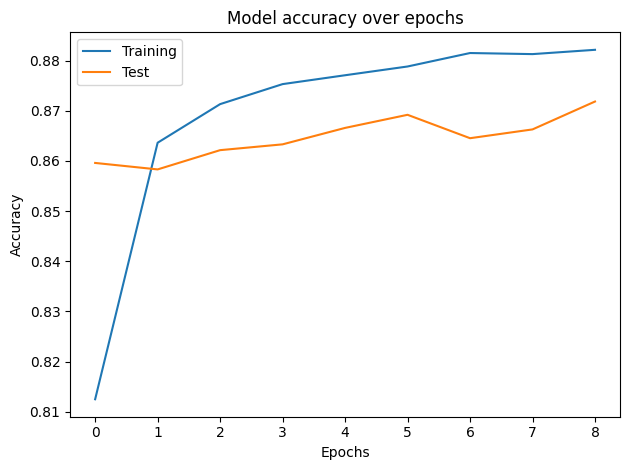

In [18]:
plt.plot(history.history['accuracy'], label = 'Training')
plt.plot(history.history['val_accuracy'], label = 'Test')
plt.title("Model accuracy over epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

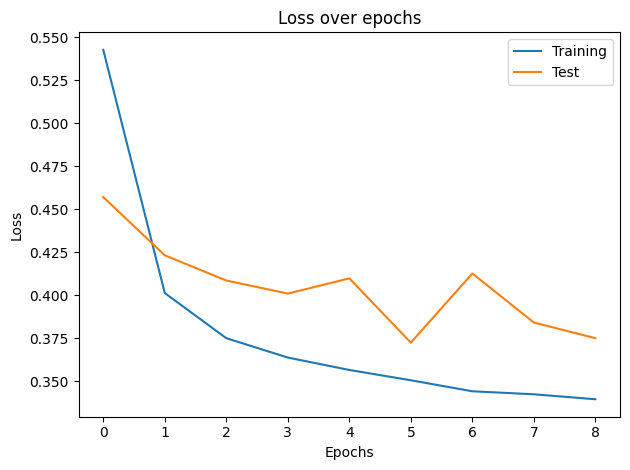

In [19]:
plt.plot(history.history['loss'], label = "Training")
plt.plot(history.history['val_loss'], label = "Test")
plt.title("Loss over epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
loss, acc = q_aware_model.evaluate(X_test, y_test)
print("Accuracy: {:.2f}%".format(acc*100))

944/944 [==============================] - 4s 4ms/step - loss: 0.3724 - accuracy: 0.8692
Accuracy: 86.92%


944/944 [==============================] - 2s 2ms/step


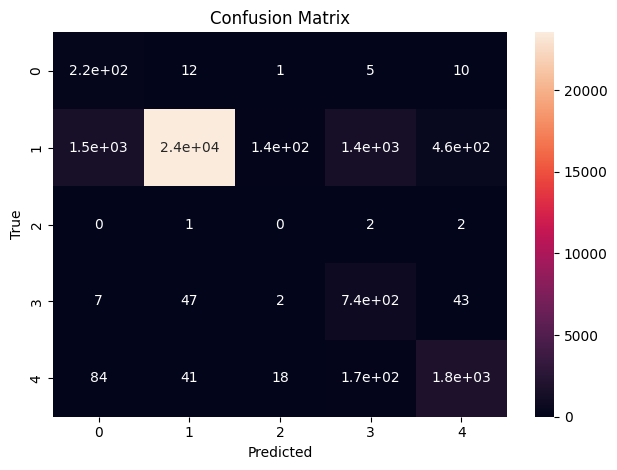

              precision    recall  f1-score   support

           F       0.12      0.88      0.21       243
           N       1.00      0.87      0.93     27042
           Q       0.00      0.00      0.00         5
        SVEB       0.32      0.88      0.47       839
         VEB       0.77      0.85      0.81      2078

    accuracy                           0.87     30207
   macro avg       0.44      0.70      0.48     30207
weighted avg       0.95      0.87      0.90     30207



In [21]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_probs = q_aware_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

report = classification_report(y_test, y_pred, target_names=encoder.classes_)
print(report)

# Converting to Tensorflow Lite

In [22]:
converter = tf.lite.TFLiteConverter.from_keras_model(q_aware_model)
tflite_model = converter.convert()
with open ("ecg-arrhythmia-model.tflite", "wb") as f:
  f.write(tflite_model)